<a href="https://colab.research.google.com/github/radhasundar/datamining/blob/main/exercise3a_multiple_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multiple Linear Regression Model - advertising dataset

## Import libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Loading the Dataset

In [ ]:
df=pd.read_csv('advertising.csv')

In [ ]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [ ]:
df.shape

(200, 4)

In [ ]:
print(df.describe())

               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


#Equation: Sales = β0 + (β1 Weight) + (β2 Volume) + e
##Setting the values for independent (X) variable and dependent (Y) variable

In [ ]:
# setting the value for X and y
X=df[['TV','Radio','Newspaper']]
y=df['Sales']


# check for outliers

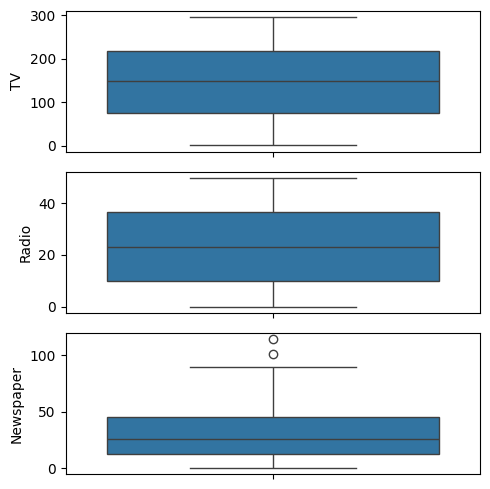

In [ ]:
fig, axs=plt.subplots(3,figsize=(5,5))
plt1=sns.boxplot(df['TV'],ax=axs[0])
plt2=sns.boxplot(df['Radio'],ax=axs[1])
plt3=sns.boxplot(df['Newspaper'],ax=axs[2])
plt.tight_layout()

Ecploratory data analysis

/tmp/ipython-input-4256165467.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Sales'])


<Axes: xlabel='Sales', ylabel='Density'>

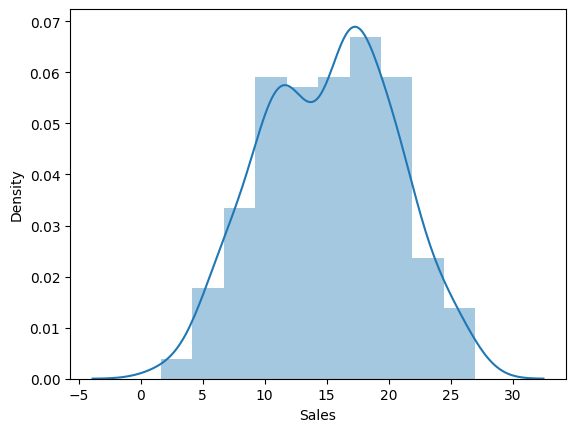

In [ ]:
sns.distplot(df['Sales'])

# the figure shows normal distribution

# Model building

##split the data set into labels and dependent columns

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

#Normalization

In [ ]:
y_train.shape

(140,)

In [ ]:
y_test.shape

(60,)

In [ ]:
# fitting the multiple linear regression model
reg_model=LinearRegression().fit(X_train,y_train)

## print the model coefficients

In [ ]:
print('Intercept: ', reg_model.intercept_)
# pair the feature names with the coefficients
print('Coefficients: ')
print(reg_model.coef_)

Intercept:  4.743766701589685
Coefficients: 
[0.05358869 0.10270677 0.00793167]


##Predicting the Test and Train set result

In [ ]:
y_pred=reg_model.predict(X_test)
x_pred=reg_model.predict(X_train)

In [ ]:
model_diff=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})

print(model_diff)

     Actual Value  Predicted Value  Difference
95           16.9        17.159919   -0.259919
15           22.4        20.533695    1.866305
30           21.4        23.689144   -2.289144
158           7.3         9.519146   -2.219146
128          24.7        21.607368    3.092632
115          12.6        12.781013   -0.181013
69           22.3        21.086363    1.213637
170           8.4         8.760542   -0.360542
174          16.5        17.115000   -0.615000
45           16.1        16.687896   -0.587896
66           11.0         8.975847    2.024153
182           8.7         8.576450    0.123550
165          16.9        18.332123   -1.432123
78            5.3         8.178636   -2.878636
186          10.3        12.646056   -2.346056
177          16.7        14.944869    1.755131
56            5.5         8.349395   -2.849395
152          16.6        17.838589   -1.238589
82           11.3        11.121722    0.178278
68           18.9        20.377406   -1.477406
124          

Error calculation

In [ ]:
from sklearn import metrics

mae=metrics.mean_absolute_error(y_test,y_pred)
mse=metrics.mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
print('MAE:',mae)
print('MSE:',mse)
print('RMSE:',rmse)
print('variance score: %2f' % reg_model.score(X_test,y_test))

MAE: 1.1594875061090582
MSE: 2.541624036229147
RMSE: 1.5942471691143587
variance score: 0.909148


# predict CO2 for a new data

In [ ]:
predictCO2=reg_model.predict([[140,50,30]])
print(predictCO2)

[17.61947191]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
